In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df.describe

<bound method NDFrame.describe of       Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0      1            5.1           3.5            1.4           0.2   
1      2            4.9           3.0            1.4           0.2   
2      3            4.7           3.2            1.3           0.2   
3      4            4.6           3.1            1.5           0.2   
4      5            5.0           3.6            1.4           0.2   
..   ...            ...           ...            ...           ...   
145  146            6.7           3.0            5.2           2.3   
146  147            6.3           2.5            5.0           1.9   
147  148            6.5           3.0            5.2           2.0   
148  149            6.2           3.4            5.4           2.3   
149  150            5.9           3.0            5.1           1.8   

            Species  
0       Iris-setosa  
1       Iris-setosa  
2       Iris-setosa  
3       Iris-setosa  
4       Iris-se

In [4]:
df.info

<bound method DataFrame.info of       Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0      1            5.1           3.5            1.4           0.2   
1      2            4.9           3.0            1.4           0.2   
2      3            4.7           3.2            1.3           0.2   
3      4            4.6           3.1            1.5           0.2   
4      5            5.0           3.6            1.4           0.2   
..   ...            ...           ...            ...           ...   
145  146            6.7           3.0            5.2           2.3   
146  147            6.3           2.5            5.0           1.9   
147  148            6.5           3.0            5.2           2.0   
148  149            6.2           3.4            5.4           2.3   
149  150            5.9           3.0            5.1           1.8   

            Species  
0       Iris-setosa  
1       Iris-setosa  
2       Iris-setosa  
3       Iris-setosa  
4       Iris-seto

In [7]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

**NOTE:** No preprocessing is required as there is not missing value and the featuresz are also nearly in same scale 

In [54]:
X=df.drop(columns=["Id","Species"])
y=df["Species"]

In [55]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# KNN

In [56]:
from sklearn.neighbors import KNeighborsClassifier
neigh_model = KNeighborsClassifier(n_neighbors=3)
neigh_model.fit(X_train, y_train)


,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [57]:
y_pred=neigh_model.predict(X_test)
print(y_pred[0],y_test.iloc[0])

Iris-versicolor Iris-versicolor


In [21]:
# acc=neigh_model.score(X_test,y_test)
# print("Accuracy of KNN model: ",acc)

In [58]:
# As mentioned in the question testing on whole dataset

acc=neigh_model.score(X,y)
print("Accuracy of KNN model: ",acc)

Accuracy of KNN model:  0.96


In [59]:
from sklearn.neighbors import KNeighborsClassifier
neigh_model = KNeighborsClassifier(n_neighbors=5)
neigh_model.fit(X_train, y_train)
acc=neigh_model.score(X,y)
print("Accuracy of KNN model: ",acc)

Accuracy of KNN model:  0.9733333333333334


In [61]:
y_pred_new=neigh_model.predict(X)

In [62]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
print("Confusion Matrix")
cm=confusion_matrix(y,y_pred_new)
print(cm)

Confusion Matrix
[[50  0  0]
 [ 0 47  3]
 [ 0  1 49]]


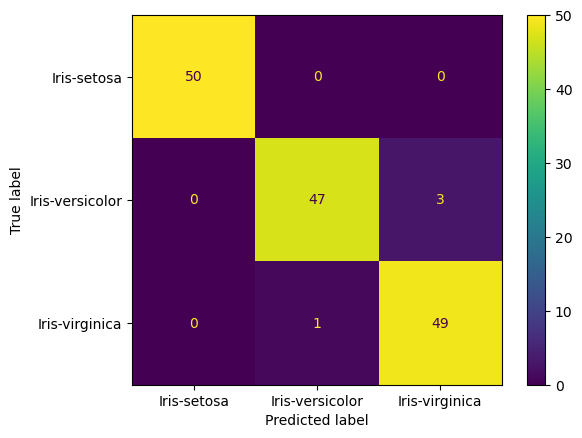

In [63]:
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=neigh_model.classes_)
disp.plot()

# LOGISTIC REGRESSION

In [64]:
from sklearn.linear_model import LogisticRegression
log_model=LogisticRegression()
log_model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [65]:
y_pred=log_model.predict(X_test)
print(y_pred[0],y_test.iloc[0])

Iris-versicolor Iris-versicolor


In [66]:
acc=log_model.score(X_test,y_test)
print("Accuracy of KNN model: ",acc)

Accuracy of KNN model:  1.0


In [67]:
# As mentioned in the question testing on whole dataset
acc=log_model.score(X,y)
print("Accuracy of KNN model: ",acc)

Accuracy of KNN model:  0.98


In [68]:
y_pred_new=naive_model.predict(X)

In [69]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
print("Confusion Matrix")
cm=confusion_matrix(y,y_pred_new)
print(cm)

Confusion Matrix
[[50  0  0]
 [ 0 47  3]
 [ 0  3 47]]


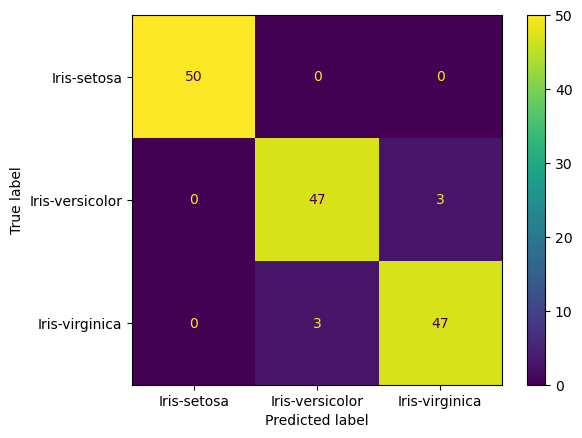

In [70]:
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=log_model.classes_)
disp.plot()

# NAIVE BAYES

In [28]:
from sklearn.naive_bayes import GaussianNB
naive_model=GaussianNB()
naive_model.fit(X_train,y_train)

,priors,None
,var_smoothing,1e-09


In [29]:
y_pred=log_model.predict(X_test)
print(y_pred[0],y_test.iloc[0])

Iris-versicolor Iris-versicolor


In [30]:
acc=log_model.score(X_test,y_test)
print("Accuracy of KNN model: ",acc)

Accuracy of KNN model:  1.0


In [31]:
# As mentioned in the question testing on whole dataset
acc=log_model.score(X,y)
print("Accuracy of KNN model: ",acc)

Accuracy of KNN model:  0.98


In [32]:
from sklearn.metrics import confusion_matrix
print("Confusion Matrix")
print(confusion_matrix(y_test,y_pred))

Confusion Matrix
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [34]:
from sklearn.metrics import classification_report
print("Classification Report")
print(classification_report(y_test,y_pred))

Classification Report
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [35]:
y_pred_new=naive_model.predict(X)

In [38]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
print("Confusion Matrix")
cm=confusion_matrix(y,y_pred_new)
print(cm)

Confusion Matrix
[[50  0  0]
 [ 0 47  3]
 [ 0  3 47]]


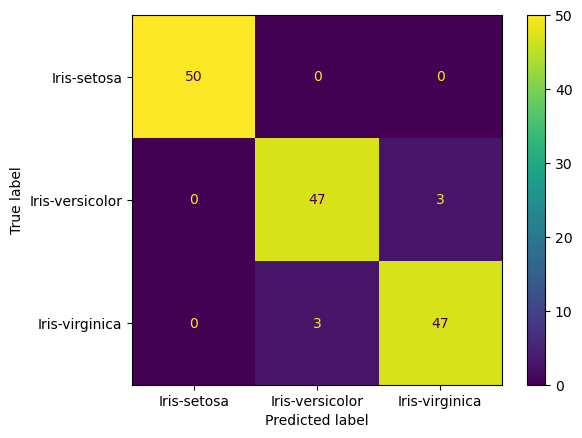

In [39]:
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=naive_model.classes_)
disp.plot()

In [37]:
from sklearn.metrics import classification_report
print("Classification Report")
print(classification_report(y,y_pred_new))

Classification Report
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        50
Iris-versicolor       0.94      0.94      0.94        50
 Iris-virginica       0.94      0.94      0.94        50

       accuracy                           0.96       150
      macro avg       0.96      0.96      0.96       150
   weighted avg       0.96      0.96      0.96       150



# COMPARISION TABLE

| **MODEL** | **ACCURACY** |
| --- | --- |
| KNN | 97.33%|
| Logistic Regression | 98% |
| Naive Bayes | 98% |